In [1]:
from option_chain_downloader import OptionChainDownloader
from option_finder import *
from option_data_plotter import *
import matplotlib.pyplot as plt

In [2]:
try:
    logger
except NameError:
    logger = get_rotating_logger("jupyter", f'logs/all_options.log')

In [3]:
chain_dir = 'chain'
quotes_dir = 'quotes'
leaps_dir = 'leaps'
data_dir = 'data'
cookie_file = 'cookie.txt'
ocd = OptionChainDownloader(chain_dir, quotes_dir, cookie_file, logger, strikes='ALL')
self = OptionFinder(logger, chain_dir=chain_dir, report_dir=data_dir)
print('OptionFinder chain_dir:', self.chain_dir)

OptionFinder chain_dir: chain


In [4]:
#symlist = ['GLD', 'QQQ'] # TLT GLD IBIT'.split(' ')
symlist = 'QQQ SPY TLT DIA IBIT ETHA GLD CRCL NVDA AAPL MSFT GOOGL'.split(' ')
#symlist = 'CRCL META AMD AMZN CRWV UNH OKLO TSLA'.split(' ')
#symlist = 'QQQ SPY TLT DIA IBIT GLD ETHA'.split(' ')

## Refresh data here

In [5]:
_t0 = time.time()
_n = ocd.download_option_chain(symlist, batch_size=5, rps=5)
print(_n, 'files downloaded in', int(time.time() - _t0), 'seconds')

24 files downloaded 4 seconds


dte,56,77,84,105,116,133,146,161,175,195,207,224,259,287,299,315,350,378,406,469
expDt,2026-01-30,2026-02-20,2026-02-27,2026-03-20,2026-03-31,2026-04-17,2026-04-30,2026-05-15,2026-05-29,2026-06-18,2026-06-30,2026-07-17,2026-08-21,2026-09-18,2026-09-30,2026-10-16,2026-11-20,2026-12-18,2027-01-15,2027-03-19


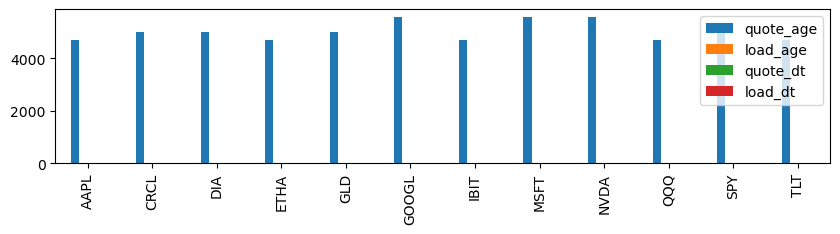

In [6]:
self.get_quote_df(symlist)
_df = self.build_option_df(symlist)
df_cp = self.concat_put_call_options(_df)
plt.rcParams['figure.figsize'] = (10, 2)
_ax = check_data_age(_df).plot(kind='bar', xlabel="")
df_cp.loc[:, ['dte', 'expDt']].groupby('dte').first().head(40).tail(20).T

In [7]:
_dfoi = df_cp[df_cp.OpenInterest > 0].pivot(columns=['type'], index=['symbol', 'dte', 'strike'], values=['OpenInterest'])
_dfoi.columns = [c[1] for c in _dfoi.columns]
_dfoi = _dfoi.reset_index().drop(columns=['dte', 'strike'])
_g = _dfoi.groupby('symbol')
pd.concat([_g.median().astype(int), _g.mean().astype(int)], axis=1)

,C,P,C,P
symbol,,,,
AAPL,326,699,3241,2689
CRCL,74,19,465,323
DIA,21,69,158,289
ETHA,551,165,2359,1467
GLD,102,119,1197,710
GOOGL,239,291,1454,1447
IBIT,1083,566,4962,2861
MSFT,230,220,1240,854
NVDA,1572,1926,5606,5430


In [128]:
plot_openinterest_hist(df_cp).groupby('symbol').quantile(0.5)

red: put, green: call


,C,P
symbol,,
DIA,6.0,22.0
ETHA,465.0,123.0
GLD,70.0,56.0
IBIT,978.0,315.0
QQQ,94.0,127.0
SPY,70.0,147.0
TLT,269.5,235.5


Volume          OpenInterest          
type          C        P            C         P
symbol                                         
DIA       11435    15357       180520    343103
ETHA      64517    26542      1302286    759586
GLD      136794    77176      3334365   1770606
IBIT     235717   105066      4846462   2503312
QQQ     1563002  1347632      3926125   5779329
SPY     2636232  2320333      5147760  11355532
TLT       79679    75577      3836646   2609296

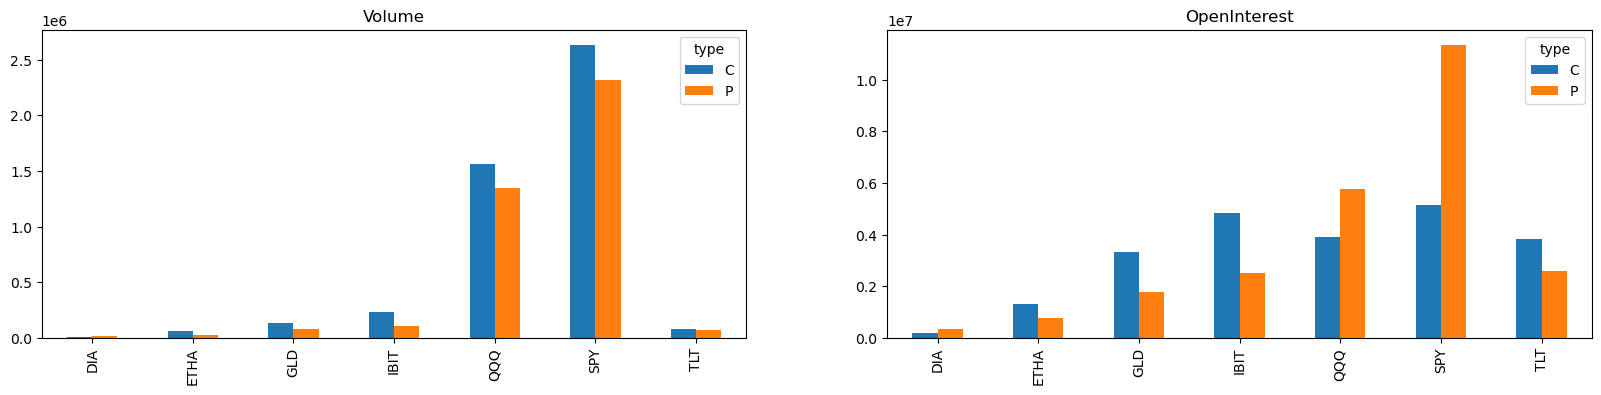

In [11]:
plot_option_volume_openinterest(df_cp)

In [12]:
df_moneyness  = add_moneyness_columns(df_cp, atm_offset=0.01, otm_offset=0.1)

Volume          OpenInterest        
type          C        P            C       P
symbol                                       
DIA        8438     3370        28242   10042
ETHA       3063      308        12422    3137
GLD       81915    41848       342191   73167
IBIT      17494     6469        91867   28693
QQQ     1363623   854562       378147  253539
SPY     2392732  1648285       731730  406571
TLT       22691    28786       210396  245694

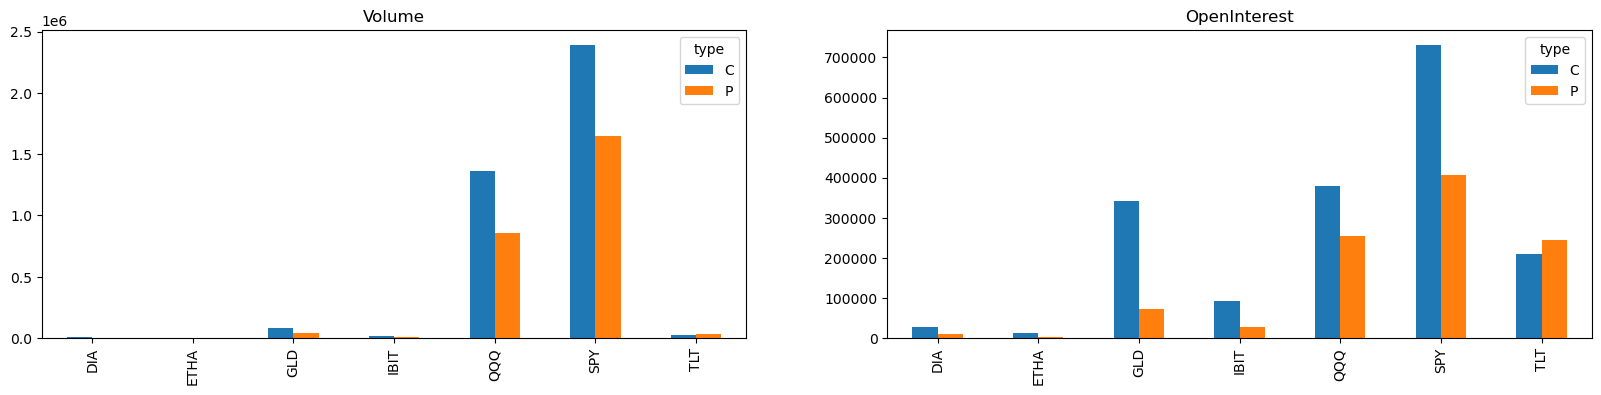

In [13]:
plot_option_volume_openinterest(df_moneyness[df_moneyness.cluster=='atm'])

### Puts/calls ratios for all strikes

,Volume_all,OpenInterest_all,Volume,OpenInterest
symbol,,,,
DIA,0.399384,0.355570,0.625000,0.323603
ETHA,0.100555,0.252536,NaN,NaN
GLD,0.510871,0.213819,0.096197,0.298717
IBIT,0.369784,0.312332,0.304348,4.421955
QQQ,0.626685,0.670477,3.681319,1.359889
SPY,0.688872,0.555630,6.136865,0.658941
TLT,1.268609,1.167769,2.047619,1.209422


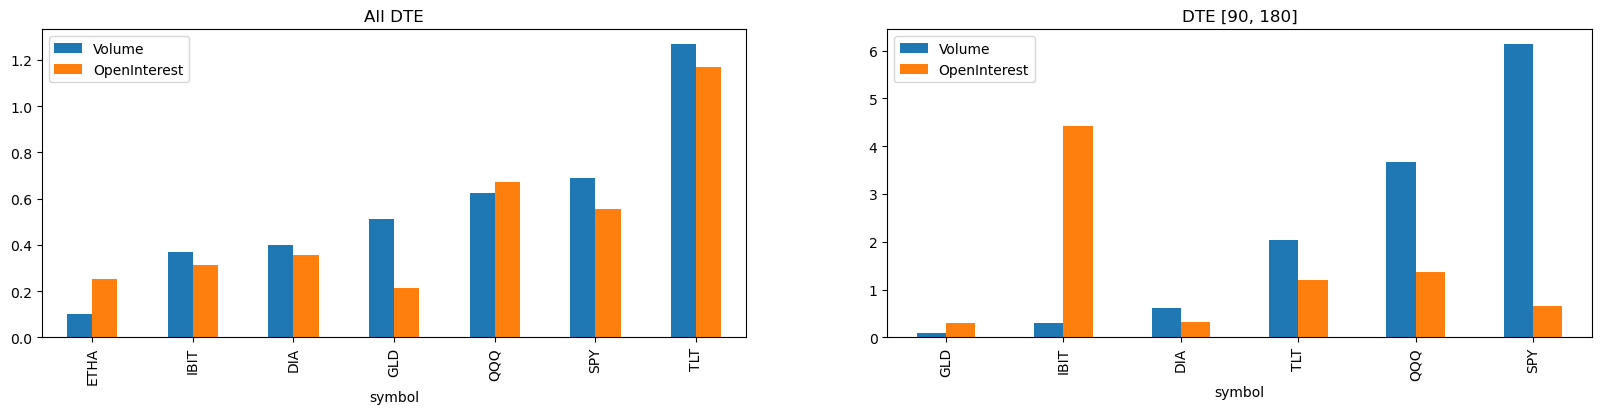

In [14]:
plot_put_call_ratios(df_cp[df_cp.cluster=='atm'], [90, 180])

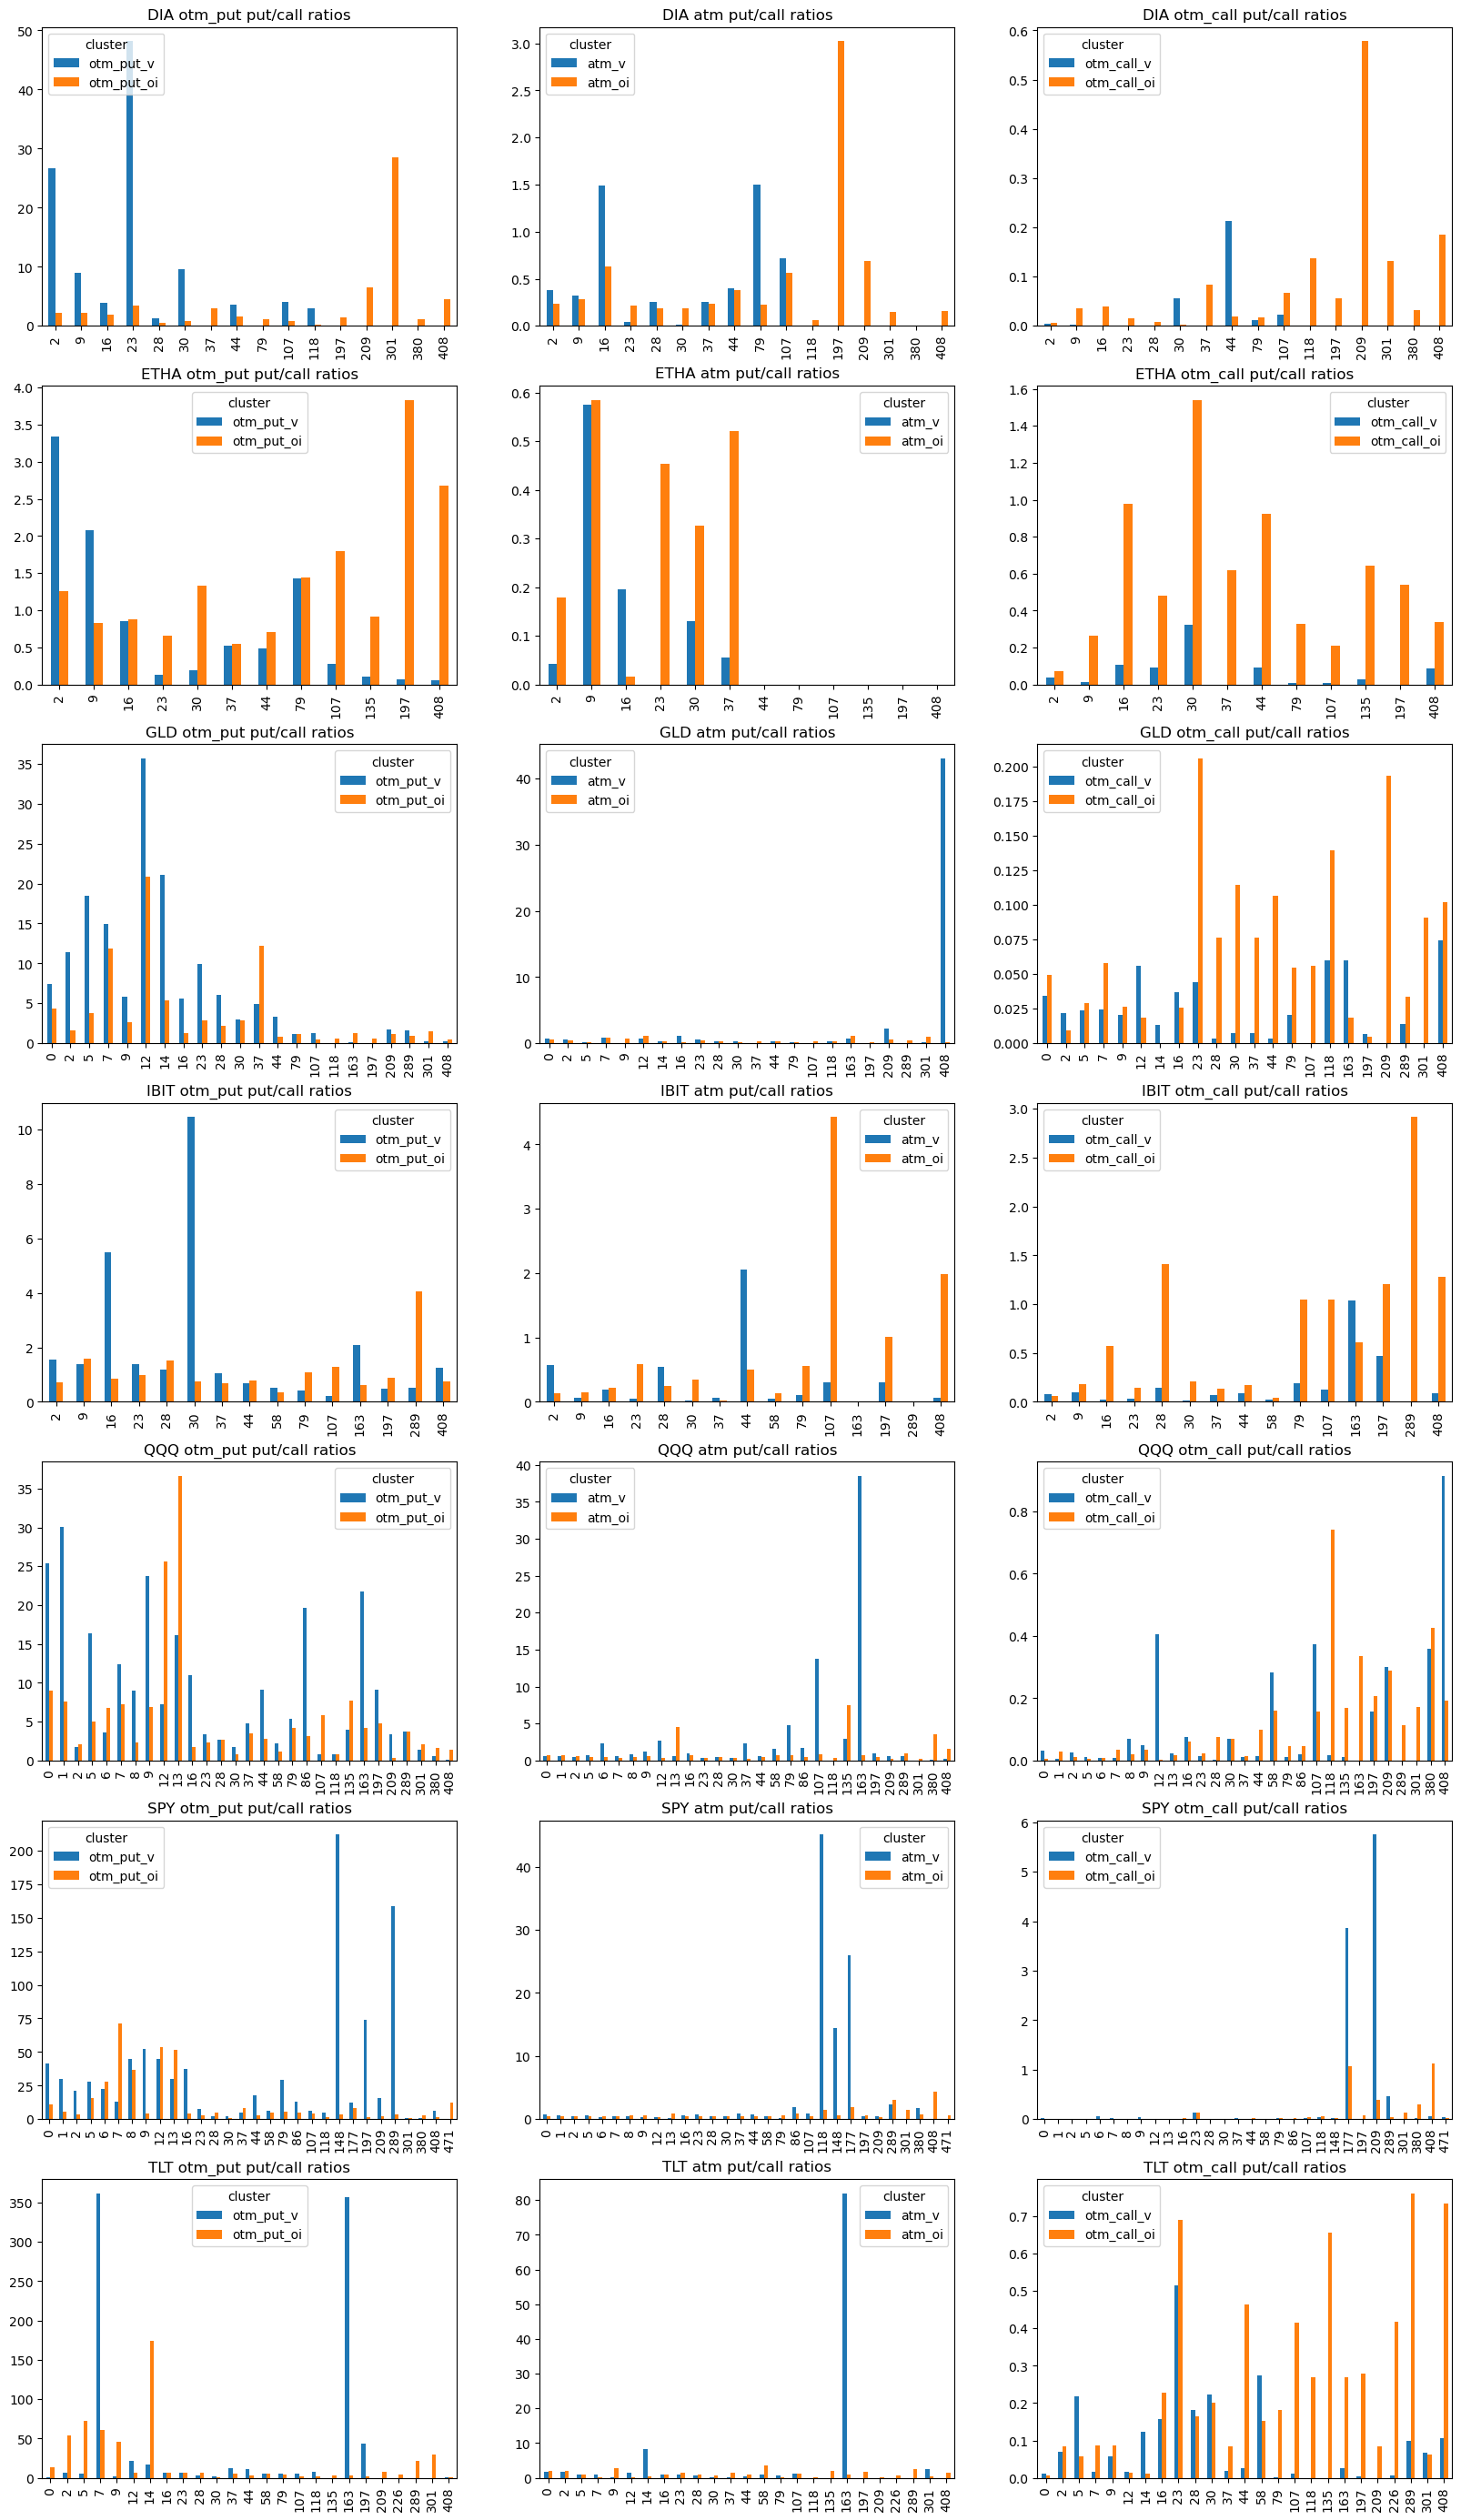

In [15]:
_df = plot_put_call_ratios_by_moneyness(df_moneyness)

In [19]:
symbol = 'TLT'
_df[_df.symbol==symbol]

cluster,symbol,dte,deep_otm_put_v,otm_put_v,atm_v,otm_call_v,deep_otm_call_v,deep_otm_put_oi,otm_put_oi,atm_oi,otm_call_oi,deep_otm_call_oi
124,TLT,0,NaN,1.042593,1.688361,0.011487,NaN,inf,13.539259,2.073303,0.007349,0.034483
125,TLT,2,NaN,6.633117,1.657413,0.070287,NaN,31.726027,54.436567,2.064807,0.083344,0.094221
126,TLT,5,NaN,4.934066,0.934990,0.218997,NaN,inf,72.219388,1.056338,0.056504,NaN
127,TLT,7,NaN,362.000000,0.906897,0.015428,NaN,6.847887,60.514658,0.286311,0.085843,0.000000
128,TLT,9,inf,1.544741,0.077160,0.056367,0.000000,57.416667,45.802347,2.746556,0.085639,0.044380
129,TLT,12,NaN,21.021505,1.385390,0.016505,0.000000,inf,6.188607,0.282131,0.014600,0.000000
130,TLT,14,NaN,17.368421,8.161290,0.123331,NaN,inf,173.666667,0.468750,0.011656,0.000000
131,TLT,16,56.200000,6.102060,1.024809,0.156663,3.846154,95.184874,7.104131,0.998354,0.227236,0.020402
132,TLT,23,inf,6.986842,0.845361,0.516304,NaN,11.288136,7.071815,1.361118,0.690989,0.014063
133,TLT,28,NaN,3.521739,0.680982,0.182377,0.244186,33.165722,7.031246,0.908694,0.163983,0.043555


red: put, green: call


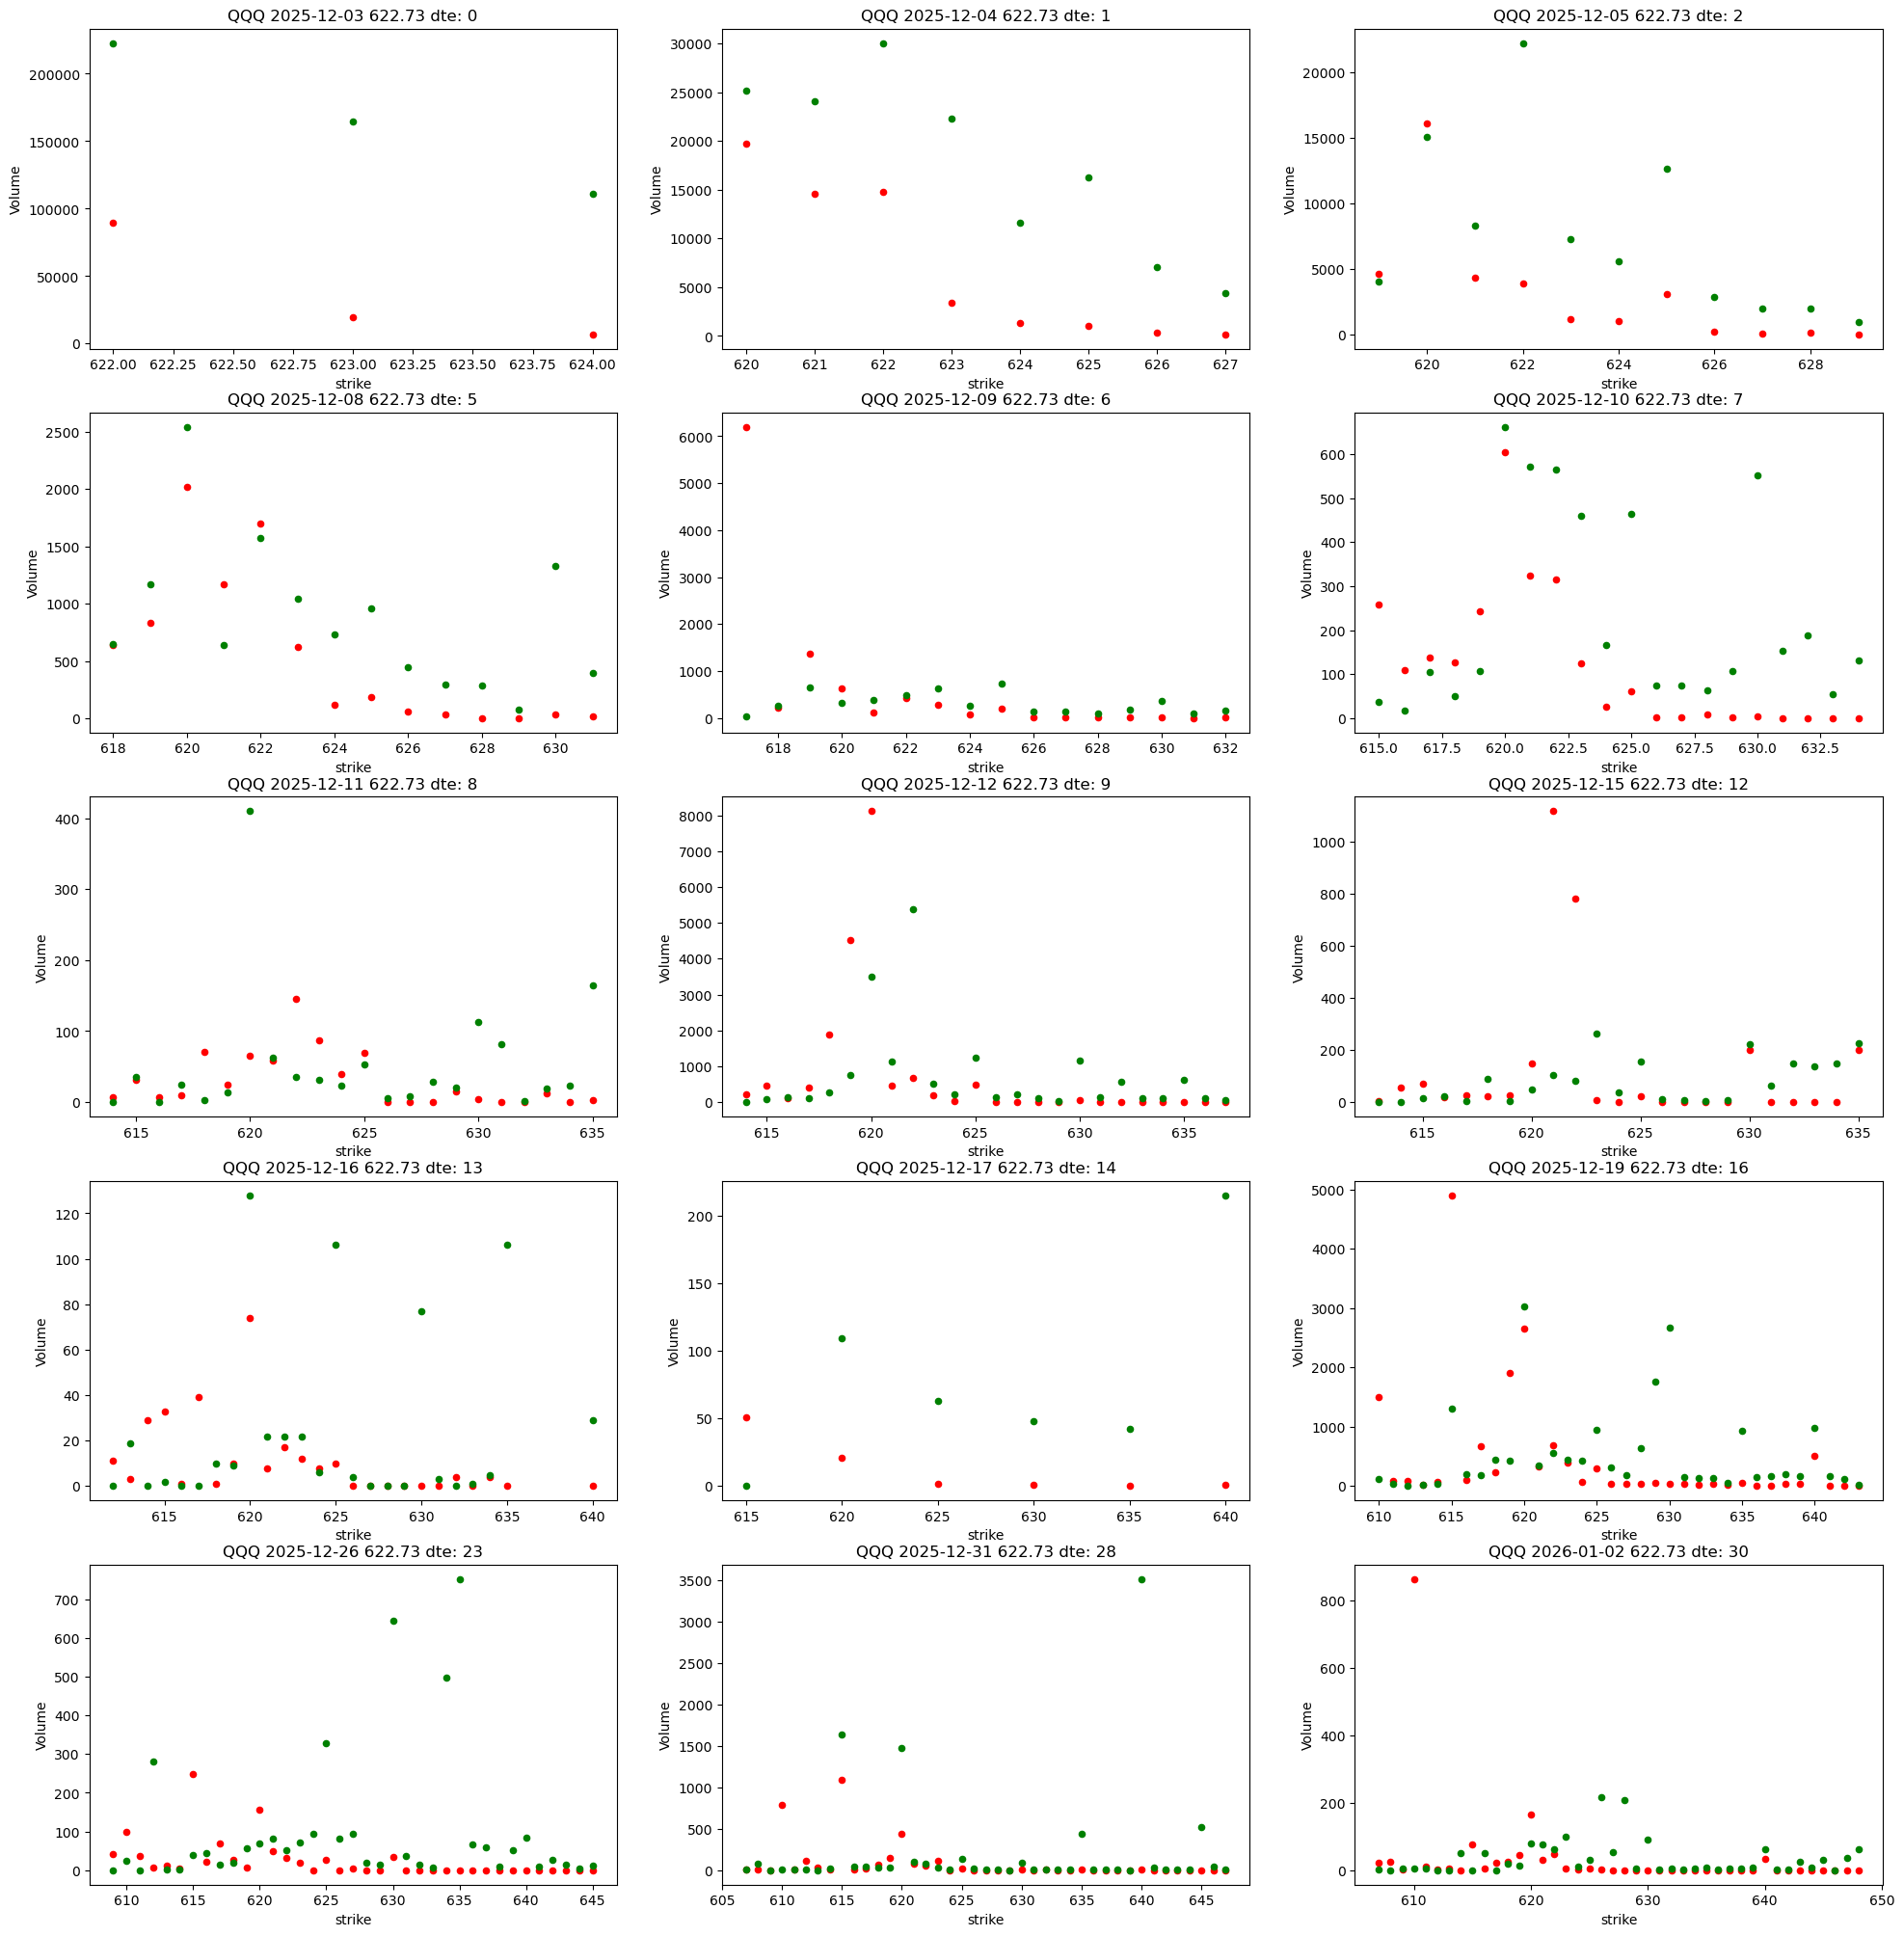

In [18]:
plot_option_details_by_dte(df_cp, symbol, 'Volume', delta_lb=0.2, delta_ub=0.7, nr=5, nc=3)

red: put, green: call


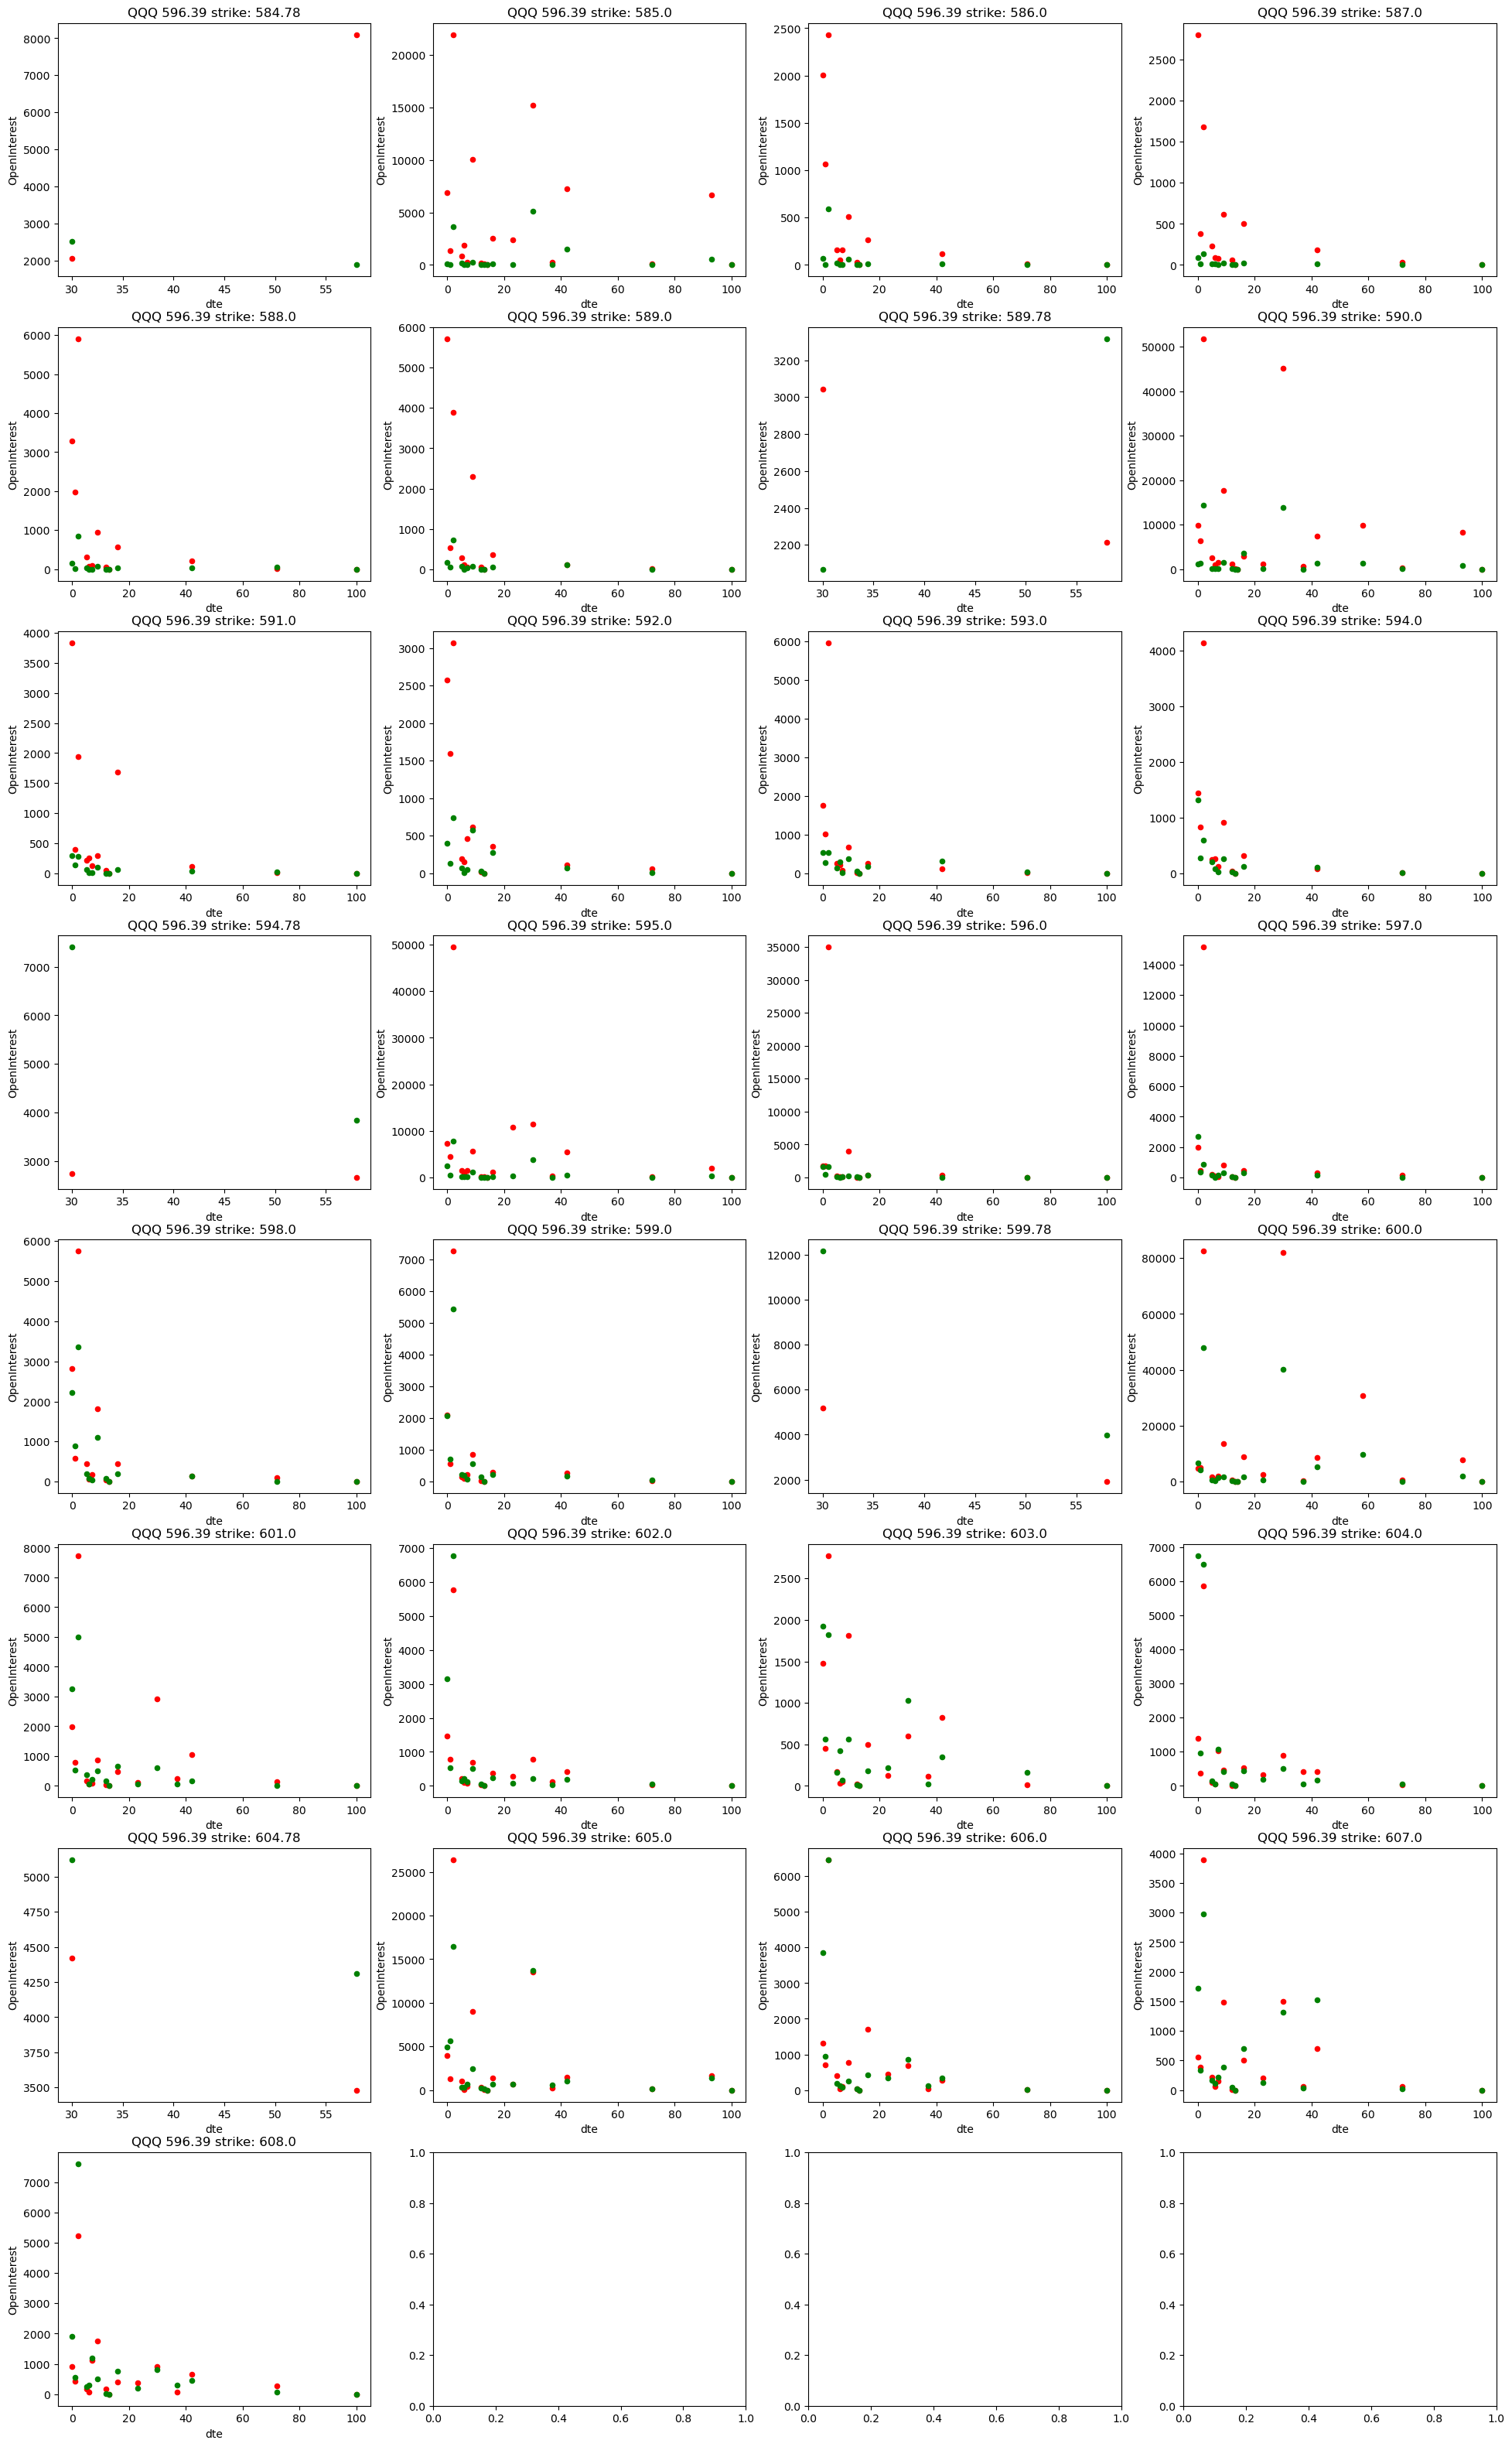

In [31]:
plot_option_details_by_strike(df_cp, 'QQQ', 'OpenInterest', [0.98, 1.02])

### The End